<a href="https://colab.research.google.com/github/raghavrakesh20/Small-projects-excersises./blob/main/Copy_of_Lyrics_Analysis_Excercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analysis of lyrics from different music traditions.

In [ ]:
# Importing necessary libraries and tools

In [ ]:
# 1. Core Data & AI
import pandas as pd             # For organizing song metadata
import numpy as np              # For numerical operations
from openai import OpenAI       # For thematic and cultural AI analysis (this will now use Deepseek API)

# 2. NLP & Linguistics
import nltk                     # Natural Language Toolkit
import re                       # Regular expressions for text cleaning
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# 3. Analysis & Visualization
from sklearn.feature_extraction.text import TfidfVectorizer # For cross-cultural pattern matching
import matplotlib.pyplot as plt # For graphing cultural signatures
import seaborn as sns           # For aesthetic data heatmaps

# 4. Initialization
# IMPORTANT: Using Deepseek API with OpenAI-compatible client
client = OpenAI(api_key="sk-0f64fdfe1edb4baf83267a43bd65718f", base_url="https://api.deepseek.com/v1")
# Download necessary NLTK components
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

print("Digital Ethnomusicology Environment: Successfully Initialized with Deepseek API.")

Digital Ethnomusicology Environment: Successfully Initialized with Deepseek API.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
songs = [
    {
        "title": "I have been a wild rover for many a year",
        "origin": "Irish",
        "language": "English",
        "lyrics": """I have been a wild rover for many a year,
And I spent all my money on whiskey and beer,
But now I've returned with gold in great store,
And I never will play the wild rover no more.
I went down to an ale house I used to frequent,
And I told the landlady my money was spent.
I asked her for credit, but she answered me "Nay.
Such custom like yours I could have any day."
I took from my pocket ten sovereigns bright,
And the landlady's eyes opened wide with delight,
She said, "I have whiskeys and wines of the best,
And I'll take you upstairs, and I'll show you the rest.
I'll go home to my parents, confess what I've done,
And I'll ask them to pardon their prodigal son.
And if they caress me as oft times before,
I never will play the wild rover no more!"""
    },
    {
        "title": "Oh, Shenandoah, I long to see you",
        "origin": "America",
        "language": "English",
        "lyrics": """Oh, Shenandoah, I long to see you,
Away, you rolling river
Oh, Shenandoah, I long to see you,
Away, I’m bound away, across the wide Missouri.
Oh Shenandoah, I love your daughter
Away, you rolling river
Oh Shenandoah, I love your daughter
Away, I’m bound away, across the wide Missouri.
Oh, Shenandoah, I’m bound to leave you,
Away, you rolling river
Oh, Shenandoah, I’m bound to leave you,
Away, I’m bound away, across the wide Missouri"""
    },
    {
        "title": "Tu gitana que adevinhas",
        "origin": "Spain",
        "language": "Spanish",
        "lyrics": """Tu gitana que adevinhas
Me lo digas pues no lo se
Si saldré desta aventura
O si nela moriré
O si nela perco la vida
O si nela triunfare
Tu gitana que adevinhas
Me lo digas pues no lo se"""
    }
]

df = pd.DataFrame(songs)
print(df)

                                      title   origin language  \
0  I have been a wild rover for many a year    Irish  English   
1         Oh, Shenandoah, I long to see you  America  English   
2                   Tu gitana que adevinhas    Spain  Spanish   

                                              lyrics  
0  I have been a wild rover for many a year,\nAnd...  
1  Oh, Shenandoah, I long to see you,\nAway, you ...  
2  Tu gitana que adevinhas\nMe lo digas pues no l...  


In [ ]:
def translate_and_clean(row):
    # Only translate if the language is Spanish
    if row['language'].lower() == 'spanish':
        response = client.chat.completions.create(
            model="deepseek-chat", # Changed model from gpt-4o to deepseek-chat
            messages=[
                {"role": "system", "content": "You are an expert ethnomusicologist and translator."},
                {"role": "user", "content": f"Translate these folk lyrics to English, preserving cultural metaphors and idiomatic meaning: {row['lyrics']}"}
            ]
        )
        return response.choices[0].message.content
    else:
        # If already English, just return the original
        return row['lyrics']

# Apply the function to create a new column for analysis
df['lyrics_analyzable'] = df.apply(translate_and_clean, axis=1)

print("Translation and normalization complete. View your 'lyrics_analyzable' column below:")
print(df[['title', 'lyrics_analyzable']])

Translation and normalization complete. View your 'lyrics_analyzable' column below:
                                      title  \
0  I have been a wild rover for many a year   
1         Oh, Shenandoah, I long to see you   
2                   Tu gitana que adevinhas   

                                   lyrics_analyzable  
0  I have been a wild rover for many a year,\nAnd...  
1  Oh, Shenandoah, I long to see you,\nAway, you ...  
2  O gypsy who can divine,\nTell me for I do not ...  


In [ ]:
def extract_themes(text):
    try:
        response = client.chat.completions.create(
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "You are an expert ethnomusicologist. Extract 3-5 key themes from the following folk song lyrics. Present them as a comma-separated list of single words or short phrases."},
                {"role": "user", "content": f"Extract themes from these lyrics: {text}"}
            ],
            temperature=0.3 # Keep creative output consistent
        )
        themes_str = response.choices[0].message.content.strip()
        # Simple parsing for comma-separated themes
        themes = [theme.strip() for theme in themes_str.split(',') if theme.strip()]
        return themes
    except Exception as e:
        print(f"Error extracting themes: {e}")
        return []

# Apply the function to the 'lyrics_analyzable' column
df['themes'] = df['lyrics_analyzable'].apply(extract_themes)

print("Theme extraction complete. View your 'themes' column below:")
print(df[['title', 'themes']])

Theme extraction complete. View your 'themes' column below:
                                      title  \
0  I have been a wild rover for many a year   
1         Oh, Shenandoah, I long to see you   
2                   Tu gitana que adevinhas   

                                              themes  
0  [reformation, redemption, repentance, temptati...  
1        [longing, journey, love, separation, river]  
2  [uncertainty, fate, divination, existential ri...  


In [ ]:
analysis_prompt = """
You are an expert ethnomusicologist specialized in cross-cultural analysis of folk song lyrics. Your task is to perform a comparative analysis of the themes from the following three folk songs, each from a different tradition:

"""

# Add themes for each song to the prompt
for index, row in df.iterrows():
    analysis_prompt += f"Song Title: {row['title']}\nOrigin: {row['origin']}\nThemes: {', '.join(row['themes'])}\n\n"

analysis_prompt += """
Based on these themes, please perform the following:
1.  Identify any overlapping symbols or themes that appear across these Irish, American, and Spanish folk song traditions.
2.  Highlight unique cultural markers or themes that are distinct to each tradition based on the provided data.
3.  Summarize how folk traditions, particularly concerning aspects like nature, family, or personal journey, might differ or converge across these regions based on the extracted themes.

Present your analysis in a clear, structured, and comparative manner.
"""

ai_analysis_response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[
        {"role": "system", "content": "You are an expert ethnomusicologist and cultural analyst. Provide detailed, insightful comparisons based on the provided themes."}, # Added system message
        {"role": "user", "content": analysis_prompt}
    ],
    temperature=0.7 # Allowing for a bit more creativity in analysis
)

# Extract and print the content of the AI's response
comparative_analysis = ai_analysis_response.choices[0].message.content
print("Cross-cultural analysis from Deepseek AI:")
print(comparative_analysis)


Cross-cultural analysis from Deepseek AI:
# Comparative Analysis of Folk Song Themes: Irish, American, and Spanish Traditions

## 1. Overlapping Symbols and Cross-Cultural Themes

**The Journey as Existential Metaphor**
All three songs employ the journey as a central metaphor for the human condition. In *I Have Been a Wild Rover*, the journey is moral and spiritual—a movement from dissipation to redemption. *Oh, Shenandoah* presents a geographical journey across rivers and landscapes, symbolizing both physical separation and emotional longing. *Tu Gitana Que Adevinhas* frames life itself as a journey through uncertainty, where one seeks guidance through uncharted existential terrain. The river appears explicitly in the American song and implicitly in the Irish (through the pub culture often associated with waterways) and Spanish (through the flow of fate), serving as a cross-cultural symbol of time, change, and passage.

**The Seeker Archetype**
Each song centers on a protagonist in a 

## Visualizing Key Themes


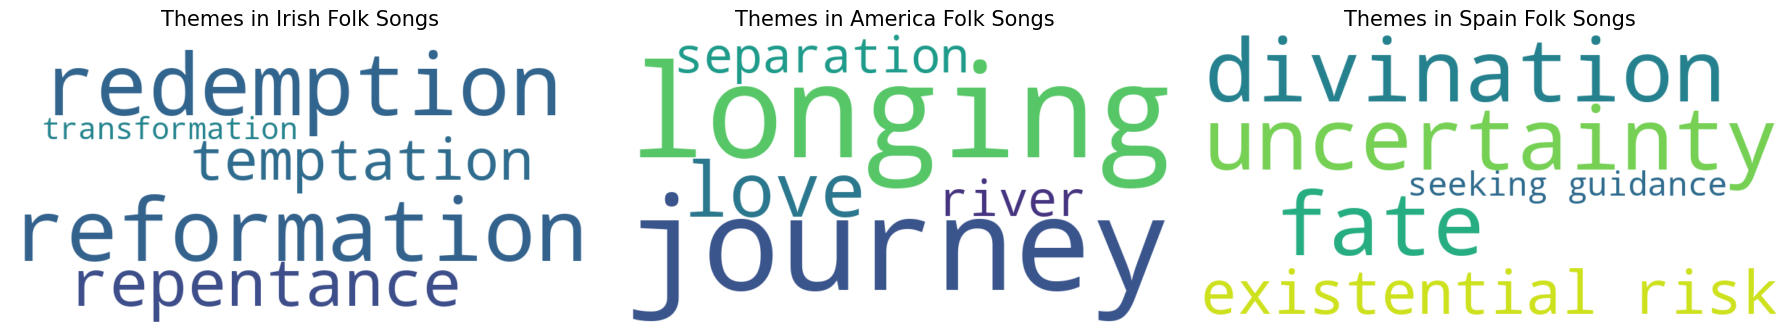

In [ ]:
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare themes for word clouds
all_themes = {}
for index, row in df.iterrows():
    origin = row['origin']
    themes = row['themes']
    if origin not in all_themes:
        all_themes[origin] = []
    all_themes[origin].extend(themes)

# Create a figure to hold all word clouds
plt.figure(figsize=(18, 10))

# Generate a word cloud for each origin
for i, (origin, themes_list) in enumerate(all_themes.items()):
    # Count theme frequencies
    theme_counts = Counter(themes_list)

    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(theme_counts)

    # Plotting
    plt.subplot(1, len(all_themes), i + 1)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Themes in {origin} Folk Songs', fontsize=15)
    plt.axis('off')

plt.tight_layout()
plt.show()
